# Notebook 10: empirical validation and dated comparisons

**Two dates, three observed snapshots.** This notebook fits original call and put spreads, retains numerical and held-out limitations, and compares fixed expiries with an explicitly interpolated 60-day horizon. The 240-bin design follows disclosed feasibility pilots; no blind temporal evaluation is claimed.

Run `python build_milestone10_notebook.py` in the extracted project folder to recompute all new results from the archived inputs. The nine previous notebooks and three earlier explorers remain unchanged.


In [1]:
from run_comparison import main as compare_observations
from build_comparison_report import main as build_comparison_report
from build_comparison_html import main as build_dated_explorer
comparison_result = compare_observations()
comparison_tables = build_comparison_report()
explorer_path = build_dated_explorer()


aug31: full fit, 840 pairs; max spread miss 1.43e-11.
aug31: coarse=solved; common-contract fit=solved.
aug31: paired holdout 1: solved.
aug31: paired holdout 2: solved.
aug31: paired holdout 3: solved.
aug31: risk ranges completed for 2026-10-16.
aug31: risk ranges completed for 2026-11-20.
aug31: risk ranges completed for 2026-12-18.
aug31: risk ranges completed for common_60_days.
sep18: full fit, 969 pairs; max spread miss 6.97e-11.
sep18: coarse=solved; common-contract fit=solved.
sep18: paired holdout 1: solved.
sep18: paired holdout 2: solved.
sep18: paired holdout 3: solved.
sep18: risk ranges completed for 2026-10-16.
sep18: risk ranges completed for 2026-11-20.
sep18: risk ranges completed for 2026-12-18.
sep18: risk ranges completed for common_60_days.
sep18_late: full fit, 950 pairs; max spread miss 6.88e-11.
sep18_late: coarse=blocked_by_spread_feasibility; common-contract fit=solved.
sep18_late: paired holdout 1: solver_failure.
sep18_late: paired holdout 2: solved.
sep18

# Notebook 10: empirical validation and dated density comparisons

## Scope and evidence

Notebook 9 established an empirical input profile but left a specific problem: its selected call-midpoint fit placed 650 of 1,938 fitted call and put prices outside their quoted spreads. This notebook changes the estimation criterion, checks compatibility with both option types, and compares the three archived snapshots. These comprise **two observation dates**, 31 August and 18 September 2026, with standard and 15-minute-later September snapshots. They are a small dated case study, not a historical time series.

As Bahra explains in his Bank of England working paper [1], option-implied densities describe risk-neutral valuation probabilities. This interpretation remains essential here: the curves are conditional on the price observations, inferred carry and chosen representation. They do not supply physical event probabilities or a known market density against which recovery accuracy can be measured.

The previous notebooks and their outputs remain the historical record. The new estimator and numerical routines live in `src/comparison.py`; the complete calculation is in `run_comparison.py`. The [offline dated explorer](interactive/dated_density_surface.html) adds observation selection, playback and a linked 60-day view. The [development reflection](research/development_reflection.md) records failed approaches as well as accepted results.

## 1. Comparable inputs and the limits of that comparison

Cboe's marking-price documentation [21] distinguishes actual exchange bid/ask observations from final indicative marks. We continue to use only the former, under Notebook 9's unchanged positive-price, ordered-spread, 25% relative-spread and 60-second message-age rules. Actual market depth is unavailable. The archived files and source-verification checksums remain unchanged. Cboe's contract and session documentation [5, 22] supplies the settlement context; the three selected contracts are SPXW PM-settled expiries. Elapsed ACT/365F time is computed in UTC, including the November civil-time change.

Table 31. Retained matched pairs, the intersection of strikes across all three snapshots, and independently inferred carry at each expiry. Times in the snapshot labels are Chicago civil time. The common-contract fit re-estimates carry on its smaller sample; the last two columns describe the all-pair fit.

| Snapshot (2026) | Expiry | Retained pairs | Common strikes | Elapsed days | Inferred D | Inferred F (points) |
|---|---|---|---|---|---|---|
| 31 Aug · 15:00 CT | 2026-10-16 | 296 | 288 | 46.00000 | 0.99742995 | 7716.6750 |
| 31 Aug · 15:00 CT | 2026-11-20 | 305 | 296 | 81.04167 | 0.99157534 | 7742.7428 |
| 31 Aug · 15:00 CT | 2026-12-18 | 239 | 230 | 109.04167 | 0.98782814 | 7762.9681 |
| 18 Sep · 15:00 CT | 2026-10-16 | 364 | 288 | 28.00000 | 0.99692766 | 7666.5433 |
| 18 Sep · 15:00 CT | 2026-11-20 | 344 | 296 | 63.04167 | 0.99259513 | 7691.7365 |
| 18 Sep · 15:00 CT | 2026-12-18 | 261 | 230 | 91.04167 | 0.98895253 | 7712.2104 |
| 18 Sep · 15:15 CT | 2026-10-16 | 361 | 288 | 27.98958 | 0.99698753 | 7680.0067 |
| 18 Sep · 15:15 CT | 2026-11-20 | 337 | 296 | 63.03125 | 0.99256973 | 7705.6095 |
| 18 Sep · 15:15 CT | 2026-12-18 | 252 | 230 | 91.03125 | 0.98914398 | 7725.9946 |

As Aït-Sahalia and Lo explain through put–call parity in their state-price-density paper [10], calls and puts are linked by the discounted forward. Equation (39) continues to estimate the discount and forward together from the relevant paired quotes. A fresh estimate is made for every snapshot, common-contract control and training fold. No external rate curve or spot/dividend series is introduced. Feasible discount projections from the carry stage are recorded in the case JSONs; the later tail bounds hold the chosen carry fixed and do not propagate this additional uncertainty.

The common strikes are intersected separately within each expiry across all three snapshots. This control reduces differences in quote composition, but also changes the carry estimates. Its contrast therefore combines sample and carry sensitivity. It is not a causal decomposition.

## 2. Ask whether the original call and put spreads can be fitted

Cohen, Reisinger and Wang discuss bid–ask-aware price restrictions and linear-programming repair in *Detecting and Repairing Arbitrage in Traded Option Prices* [23]. Their repair formulation allows soft quote bounds when needed. Here we use that discussion to motivate a compatibility diagnostic, then impose hard original bounds within our finite density representation. We do not implement their repair algorithm or modify the quotes.

For matched pair $i$ at maturity $m$, put–call parity converts both observed intervals into one call-price interval:

$$
\ell^C_{mi}=\max\{B_{mi,C},\ B_{mi,P}+D_m(F_m-K_{mi})\},\qquad
u^C_{mi}=\min\{A_{mi,C},\ A_{mi,P}+D_m(F_m-K_{mi})\}.
\tag{41}
$$

Equation (41) is our endpoint rearrangement of Equation (7). The fitted call must lie in this intersection; its parity-implied put then lies in the original put spread as well. All prices in this equation are in index points.

Let $\mathcal P_J$ contain the nonnegative bin masses with unit total mass, unit normalised mean and the within-snapshot calendar ordering of Equations (14), (18) and (19). The common support is $[0.3,2.2]$ in forward coordinates. With the exact call-price map $\mathbf A_m$ from Equation (11), the diagnostic is

$$
\delta_J^*=\min_{\delta\ge0,\,W\in\mathcal P_J}\delta
\quad\text{subject to}\quad
\ell^C_{mi}-\delta\le(\mathbf A_m\mathbf w_m)_i\le u^C_{mi}+\delta
\quad\text{for every }m,i.
\tag{42}
$$

As Boyd and Vandenberghe explain in *Convex Optimization* [11], a linear objective with linear restrictions defines an LP. Equation (42) uses this structure, with analytical calendar refinement supplying any missing within-bin restrictions. Its widening is **diagnostic only**. A positive value blocks that grid's hard-bound fit; the widened intervals are never used for estimation. A failure is conditional on the fixed carry, finite support and bin basis. It is not evidence of model-independent market arbitrage.

Table 32. The disclosed 120/240-bin feasibility comparison and subsequent hard-bound QP outcome. Positive row multipliers give algebraically equivalent constraints; failed numerical attempts are retained. A printed zero is the LP's numerical result, subject to the residual checks below.

| Snapshot | Bins | Minimum widening (points) | Final outcome | Equivalent quote-row multiplier: status |
|---|---|---|---|---|
| 31 Aug · 15:00 CT | 120 | 0 | Solved | 1: solved |
| 31 Aug · 15:00 CT | 240 | 0 | Solved | 1: solved |
| 18 Sep · 15:00 CT | 120 | 0 | Solved | 1: postcheck_failure, 10: solved |
| 18 Sep · 15:00 CT | 240 | 0 | Solved | 1: solved |
| 18 Sep · 15:15 CT | 120 | 0.0265641741 | Blocked on this grid | No QP attempted |
| 18 Sep · 15:15 CT | 240 | 0 | Solved | 1: solved |

The preliminary independent-maturity LP also required about 0.026564 index points of widening for the late 120-bin representation. Adding calendar restrictions did not create that incompatibility. The 240-bin representation is feasible with the original quotes, so it becomes the common primary grid for all three snapshots. This choice followed inspection of the feasibility pilots across all snapshots; none of these dates is an untouched temporal test set. The 120-bin controls remain available in `results/comparison_cases/`.

## 3. Choose a smooth density inside the feasible family

Driscoll and Braun's finite-difference treatment [7] supplies the second-difference stencil. Boyd and Vandenberghe's discussion of smoothing [11] motivates using a curvature criterion to choose among compatible curves. Define $\mathcal F_J$ as the subset of $\mathcal P_J$ satisfying Equation (41) without widening. We solve

$$
\widehat W=\arg\min_{W\in\mathcal F_J}\mathcal R_J(W),\qquad
\mathcal R_J(W)=\frac{1}{J-2}\sum_{m=1}^{M}\sum_{j=2}^{J-1}
\left(\frac{w_{m,j+1}-2w_{mj}+w_{m,j-1}}{\Delta u}\right)^2.
\tag{43}
$$

The squared differences are differences of density heights. For a fixed equal-width grid, this objective is a positive multiple of the roughness in Equation (21), and hence has the same minimisers when used alone. Unlike Equation (12), it does not trade midpoint error against a smoothing coefficient. All accepted quotes enter as hard restrictions, so a favourable in-sample spread count is part of the construction. It is not independent evidence that the selected density is correct. The finite support, resolution and curvature convention still influence the result.

As Goulart and Chen describe in their Clarabel paper [15], numerical status depends on specified feasibility and optimality criteria. We retain explicit curvature residuals instead of forming their normal-equation product. An initial physical-price formulation returned `AlmostSolved` for the September full fit. Multiplying the objective by 0.1, 10 or 100 did not achieve the strict status. Dividing each quote row and its bounds by the corresponding forward did, without altering its feasible set. The accepted QPs require `Solved` at $10^{-11}$ solver tolerances, as well as independent checks in the original price units.

That distinction matters: the first 120-bin September run returned `Solved` yet missed a physical-price bound by $2.97\times10^{-7}$ points, above the declared $10^{-7}$ counting tolerance. The revised runner retains such failures and tries equivalent positive quote-row multipliers of 1, 10 and 100. Multiplier 10 resolves this case without changing quotes or acceptance tolerances. This numerical retry rule was introduced after that failure and is disclosed in `comparison_protocol.json`.

16 of 18 attempted QP cases were accepted (48 marginal fits). The late 120-bin control was blocked by the feasibility check; the first late-snapshot holdout fold failed the declared numerical acceptance rule. All accepted fits passed the probability and full-interval calendar checks. The smallest final calendar gap was -6.581e-10; the largest accepted training-spread miss was 8.183e-08 index points, below the counting tolerance of $10^{-7}$. The smallest signed mass was -1.9e-15, retained without clipping. Seventy-two tail-extremum LPs completed; their independent physical-price residual limit was $2\times10^{-6}$ points.

Gatheral and Jacquier's calendar-ordering argument [12] supports the within-snapshot normalised call restrictions under the project's deterministic-carry/proportional-dividend assumptions. No calendar inequality is imposed between different observation dates. Tiny signed numerical residuals are reported as such; no mass clipping or renormalisation is performed.

Table 33. Original call/put spread diagnostics and midpoint RMSE. The September 120-bin control changes the criterion while retaining Notebook 9's bin count. The 240-bin comparison changes both criterion and resolution. All counts use the stated $10^{-7}$-point tolerance.

| Snapshot | Estimator | Expiry | Call RMSE (points) | Put RMSE (points) | Calls / puts outside | Largest miss (points) |
|---|---|---|---|---|---|---|
| 31 Aug · 15:00 CT | 240-bin constrained | 2026-10-16 | 3.2961 | 3.3985 | 0 / 0 | 1.38e-11 |
| 31 Aug · 15:00 CT | 240-bin constrained | 2026-11-20 | 3.1513 | 2.8919 | 0 / 0 | 1.06e-11 |
| 31 Aug · 15:00 CT | 240-bin constrained | 2026-12-18 | 2.7834 | 2.4480 | 0 / 0 | 1.03e-11 |
| 18 Sep · 15:00 CT | 240-bin constrained | 2026-10-16 | 0.7861 | 0.5697 | 0 / 0 | 6.96e-11 |
| 18 Sep · 15:00 CT | 240-bin constrained | 2026-11-20 | 0.7695 | 0.6337 | 0 / 0 | 6.3e-11 |
| 18 Sep · 15:00 CT | 240-bin constrained | 2026-12-18 | 0.7234 | 0.5273 | 0 / 0 | 6.11e-11 |
| 18 Sep · 15:15 CT | 240-bin constrained | 2026-10-16 | 0.4469 | 0.2602 | 0 / 0 | 6.89e-11 |
| 18 Sep · 15:15 CT | 240-bin constrained | 2026-11-20 | 0.4221 | 0.2530 | 0 / 0 | 2.06e-12 |
| 18 Sep · 15:15 CT | 240-bin constrained | 2026-12-18 | 0.4846 | 0.3167 | 0 / 0 | 2.33e-12 |
| 18 Sep · 15:00 CT | Notebook 9 primary | 2026-10-16 | 0.8895 | 1.0036 | 100 / 236 | 1.866071 |
| 18 Sep · 15:00 CT | Notebook 9 primary | 2026-11-20 | 0.4477 | 0.8228 | 36 / 145 | 1.368845 |
| 18 Sep · 15:00 CT | Notebook 9 primary | 2026-12-18 | 0.3323 | 0.7146 | 6 / 127 | 0.630488 |
| 18 Sep · 15:00 CT | 120-bin constrained | 2026-10-16 | 0.7915 | 0.5688 | 0 / 0 | 0.000000 |
| 18 Sep · 15:00 CT | 120-bin constrained | 2026-11-20 | 0.7661 | 0.6341 | 0 / 0 | 0.000000 |
| 18 Sep · 15:00 CT | 120-bin constrained | 2026-12-18 | 0.7191 | 0.5289 | 0 / 0 | 0.000000 |



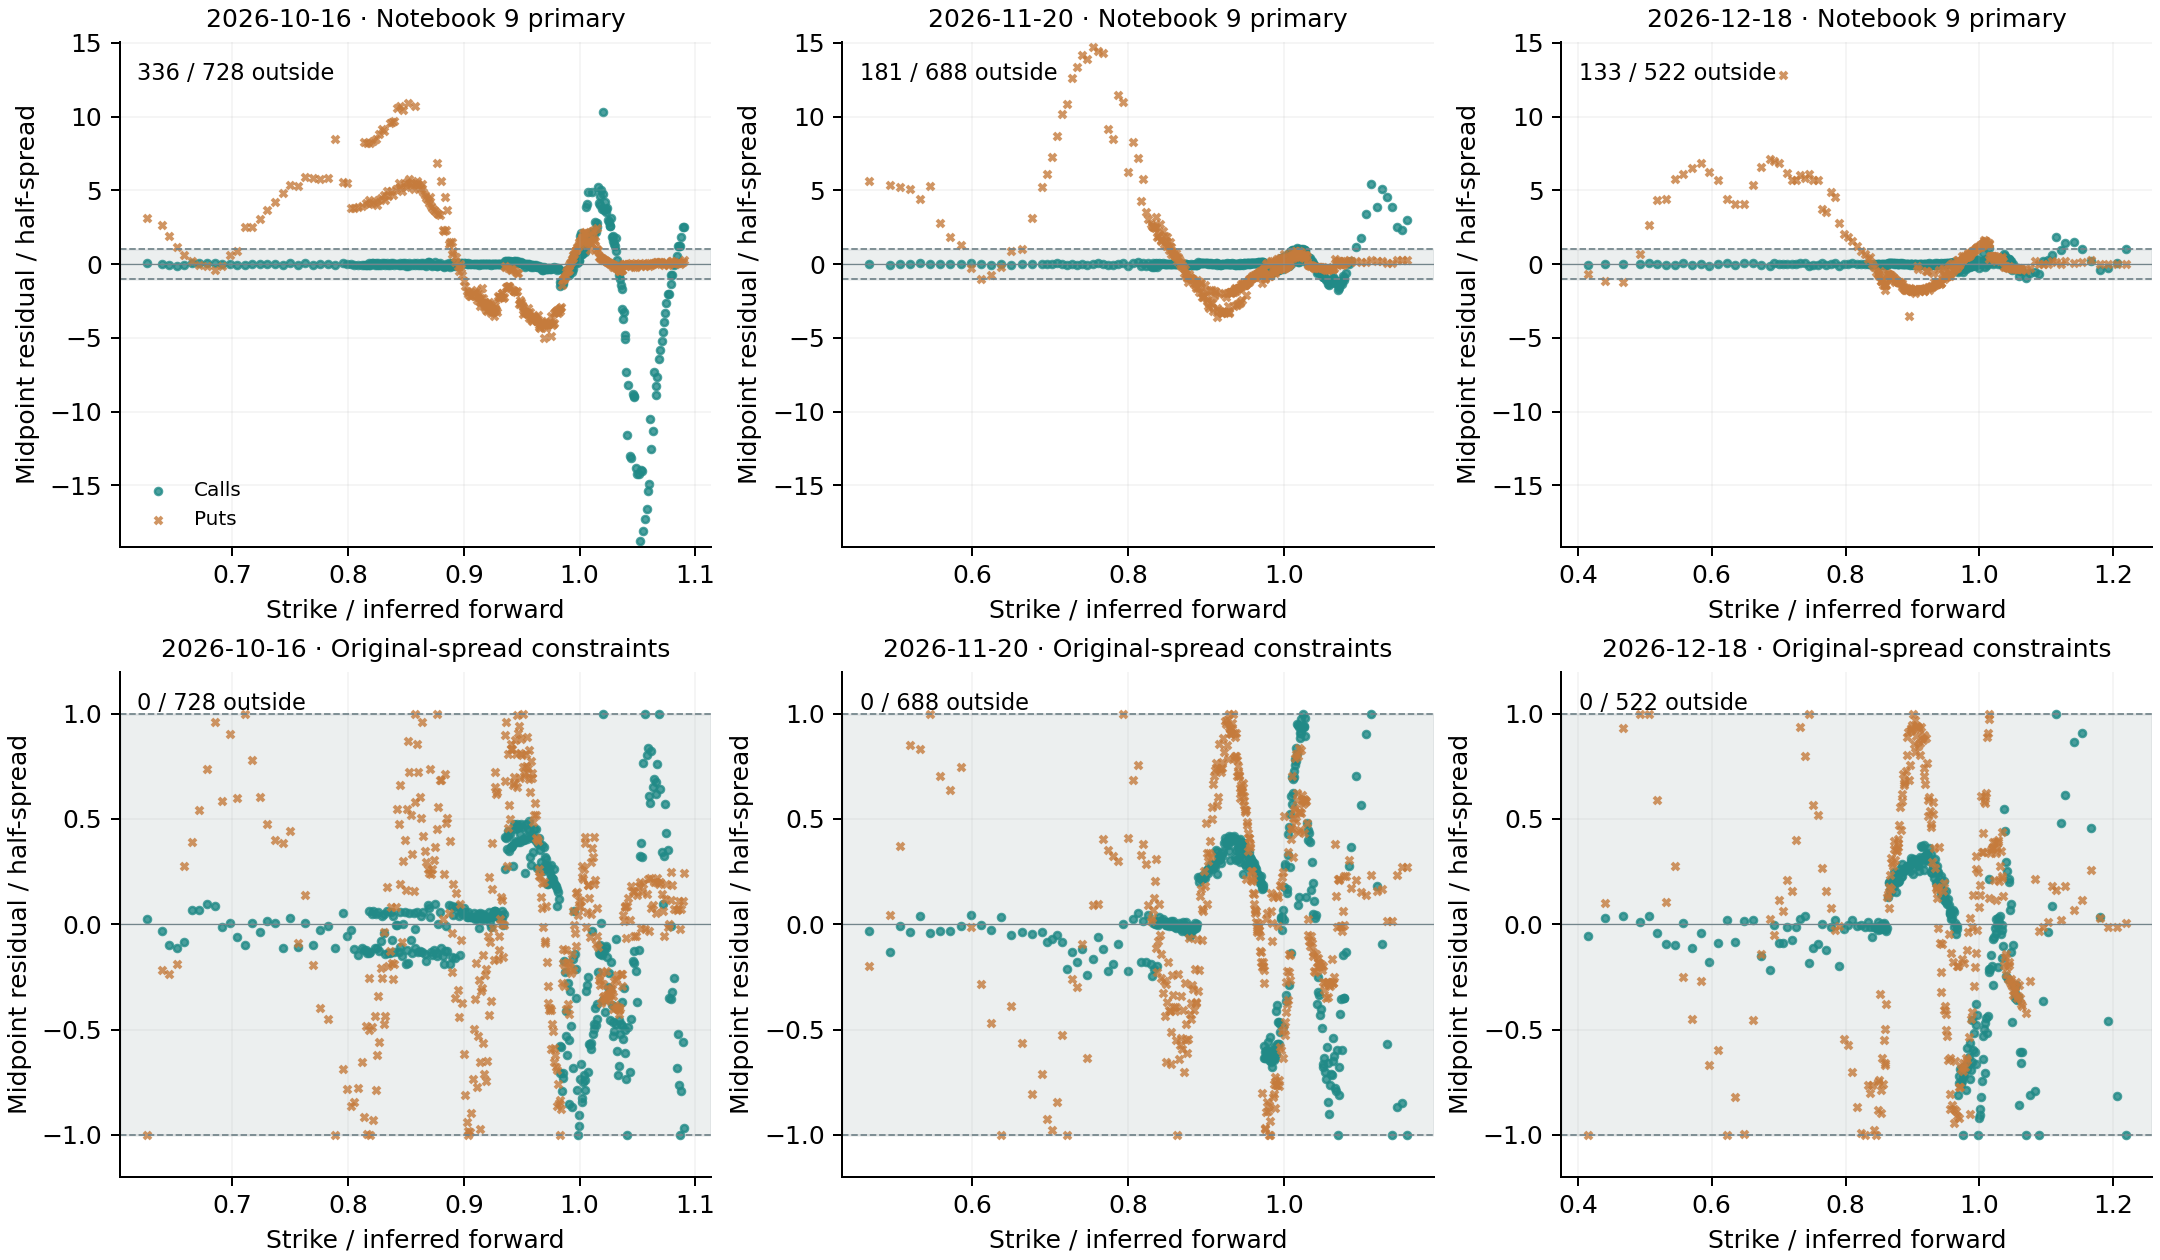




Figure 29. Standard September snapshot: Notebook 9's selected 120-bin midpoint fit above, and the new 240-bin original-spread fit below. Shading spans the quoted bid–ask interval in half-spread units. The upper and lower rows have different vertical scales, and all residuals are displayed. The 120-bin hard-bound control also has zero counted spread misses; the September improvement therefore does not require the finer grid.

## 4. Evaluate withheld pairs, and retain the failed case

As Cawley and Talbot discuss in their model-selection paper [17], evaluation can be biased when decisions are made using the same evidence. The three interlaced folds here are descriptive checks of interpolation across strikes after the disclosed design work. They do not select a penalty and are not a blind estimate of future-date performance. Endpoints remain in training. Each held strike loses both its call and put, and Equation (39) is re-estimated using training pairs only before fitting the density.

Table 34. Held-out call and put errors. Each successful fold contributes its actual quote count to the pooled forward-scaled midpoint MSE. The late snapshot has only two accepted folds, so its score must not be treated as directly comparable complete-fold evidence.

| Snapshot | Solved folds | Evaluated quotes | Outside spreads | Outside (%) | Largest miss (points) | Pooled normalised MSE |
|---|---|---|---|---|---|---|
| 31 Aug · 15:00 CT | 3 / 3 | 1668 | 40 | 2.398 | 0.872056 | 1.496021e-07 |
| 18 Sep · 15:00 CT | 3 / 3 | 1926 | 46 | 2.388 | 0.392571 | 7.838472e-09 |
| 18 Sep · 15:15 CT | 2 / 3 | 1256 | 24 | 1.911 | 0.058489 | 2.261022e-09 |

The first late-snapshot fold is price-feasible in the LP, but its QP fails the separate numerical rule: multiplier 1 returns `Solved` with a $1.29\times10^{-7}$-point physical bound miss; multipliers 10 and 100 return `AlmostSolved`. It is retained as `sep18_late_fold0.json`, with training/held membership and every numerical attempt, and excluded from the aggregate with coverage explicitly shown. This is an unresolved numerical limitation, not a proof that its quotes are incompatible. The successful folds also leave some held-out prices outside their spreads. Exact in-sample compatibility does not transfer automatically to unseen strikes.

## 5. Distinguish a selected tail estimate from its feasible range

As Malz explains in his option-based-distribution study [14], tail summaries depend on interpolation and extrapolation choices. To examine this directly, we remove the curvature objective and optimise each risk event over the entire original-spread-feasible family. For a fixed event with bin-fraction coefficients $\mathbf a$,

$$
\underline p_J(\mathbf a)=\min_{W\in\mathcal F_J}\mathbf a^{\mathsf T}\operatorname{vec}(W),\qquad
\overline p_J(\mathbf a)=\max_{W\in\mathcal F_J}\mathbf a^{\mathsf T}\operatorname{vec}(W).
\tag{44}
$$

The coefficients are exact within-bin event fractions, with time-mixture weights included for the common horizon below. All maturities stay jointly constrained while an event at one horizon is optimised. These LP bounds are **conditional feasible ranges, not confidence intervals**. They hold the all-pair carry, 240-bin support, original selected quotes and interpolation convention fixed. Carry uncertainty, different supports, unobserved quotes and sampling uncertainty are outside their scope. They are not asserted to be sharp bounds over all possible distributions.

## 6. Separate fixed-expiry change from the passage of time



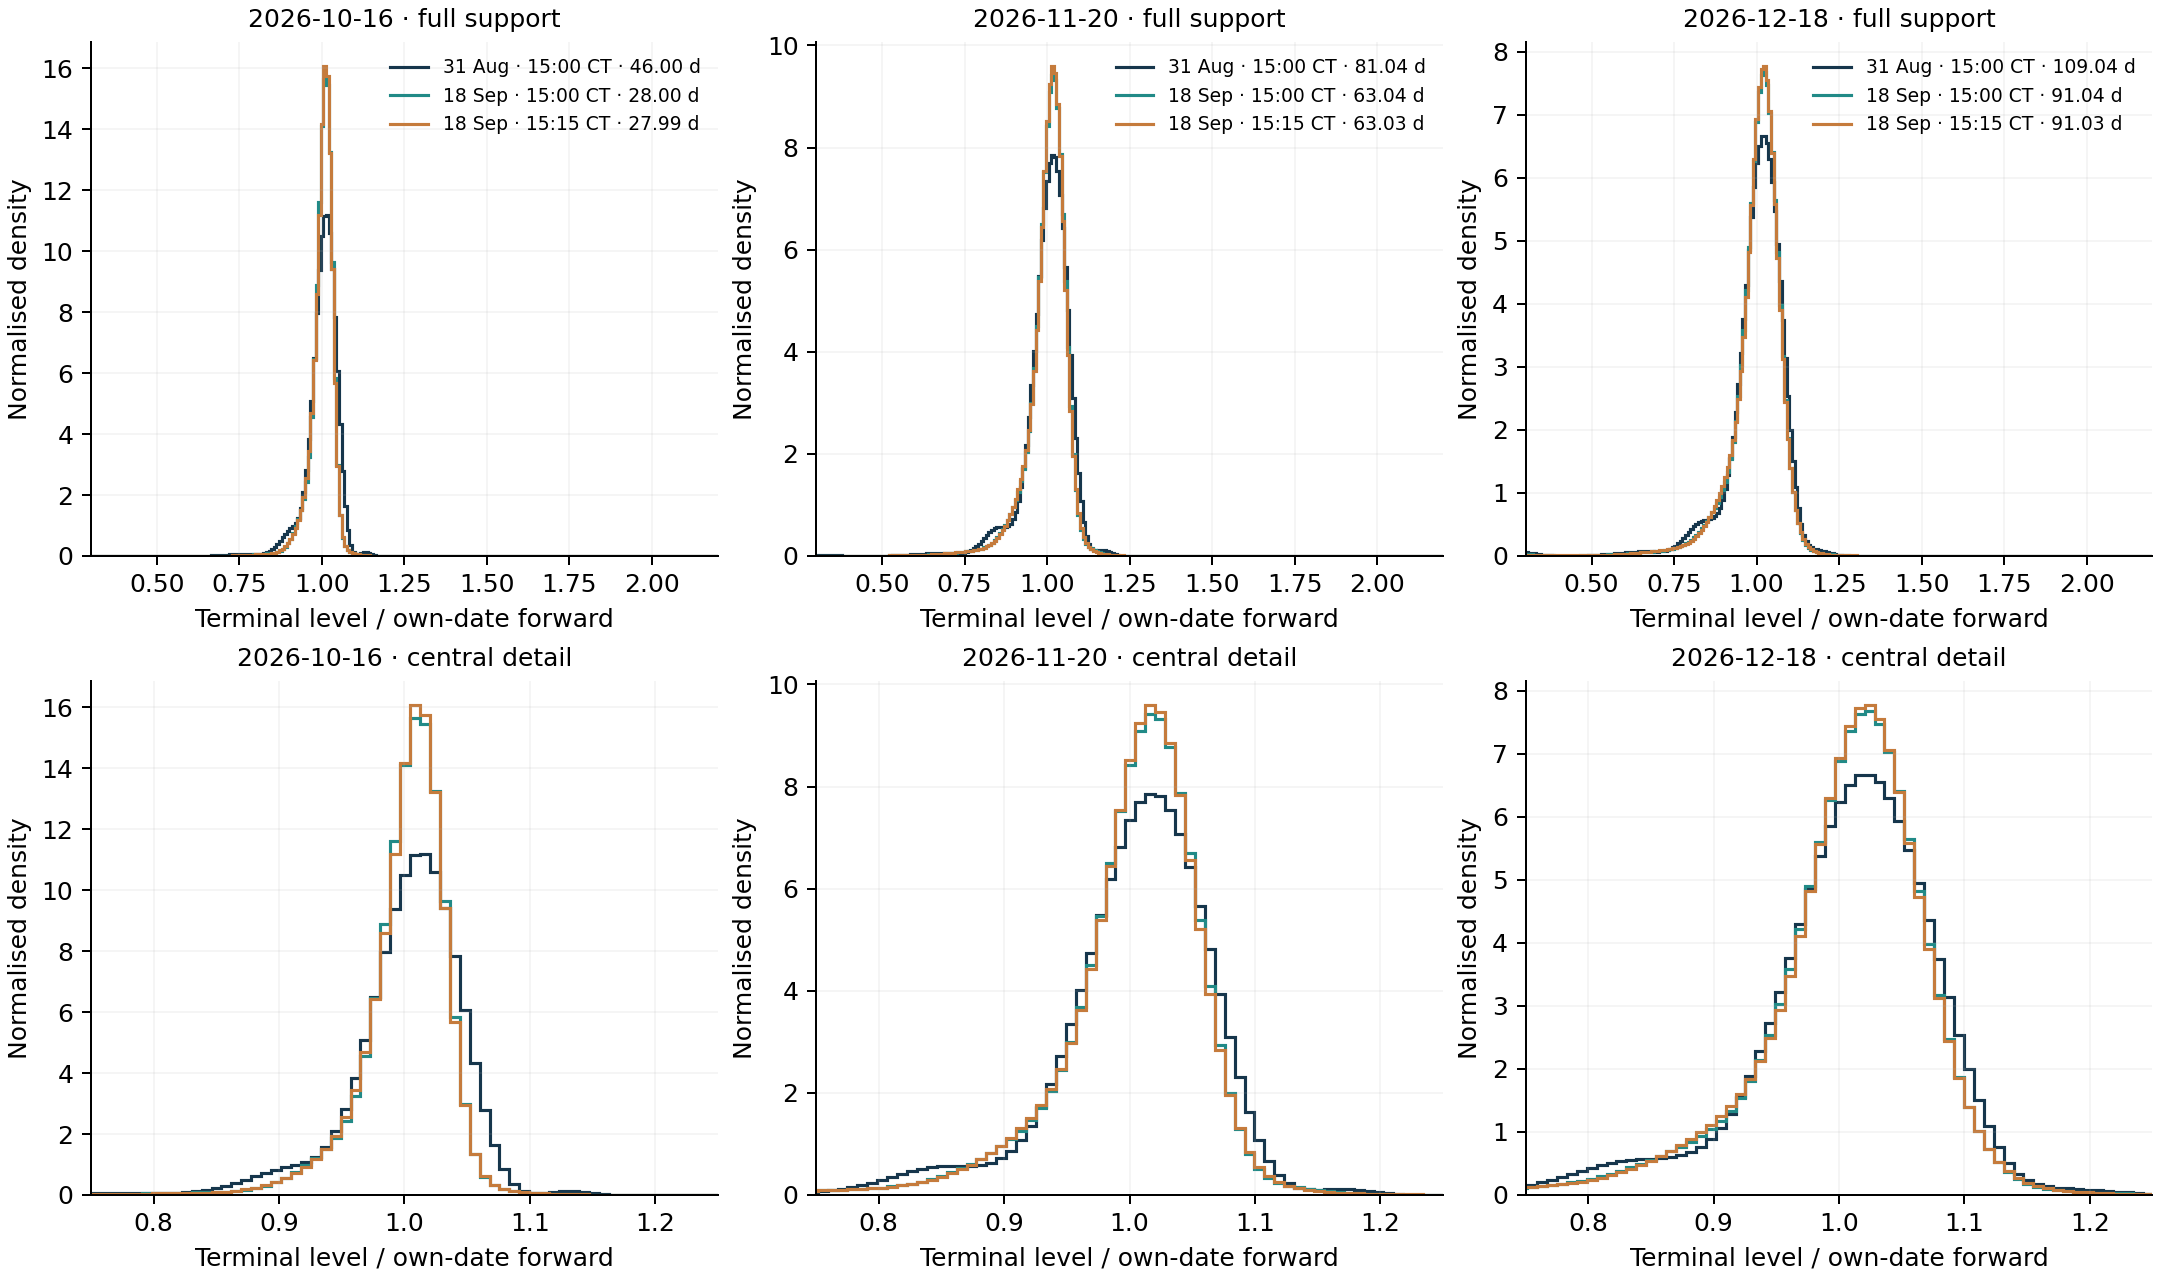




Figure 30. Fixed-expiry density comparisons, with full support above and central detail below. The elapsed horizon falls by 18 days between August and standard September, and by another 15 minutes at the later snapshot. Each curve uses its own inferred forward; the same normalised threshold can therefore correspond to different index levels. These curves cannot isolate a pure change in expectations at a fixed horizon.

For a complementary comparison we explicitly assume a linear mixture between the two adjacent normalised maturity distributions bracketing $T_*=60$ elapsed days. With all times expressed in the same unit,

$$
\omega_* = \frac{T_*-T_a}{T_b-T_a},\qquad
\mathbf w_*=(1-\omega_*)\mathbf w_a+\omega_*\mathbf w_b,\qquad
T_a\le T_*\le T_b.
\tag{45}
$$

Equation (45) is a project interpolation convention, not an empirically observed 60-day density or an equation borrowed from a source. It preserves nonnegativity, unit mass and unit normalised mean. Because normalised call valuation is linear in the masses, call curves mix by the same weights and remain ordered between the adjacent endpoints. We do not extrapolate or invent a 60-day discount or forward. The common-horizon outputs remain in normalised coordinates; their thresholds describe the assumed interpolated variable. The three actual maturity rows in the 3D view remain distinct from that additional assumed slice.



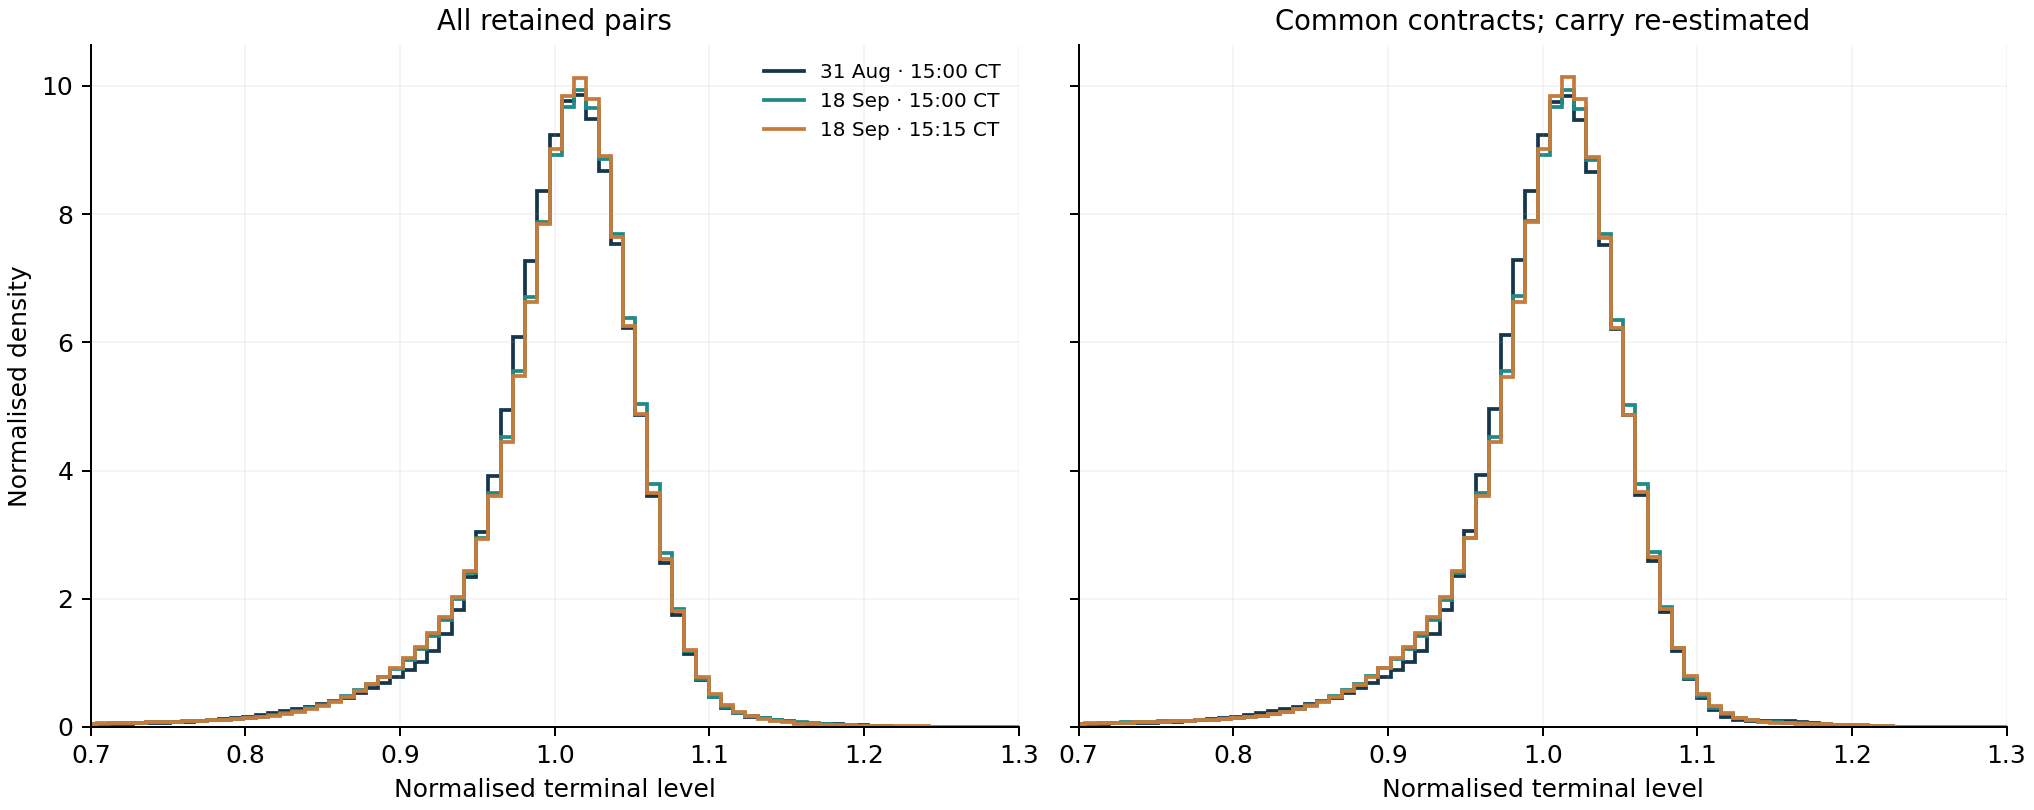




Figure 31. Interpolated 60-day normalised density using all retained pairs, and the separately re-estimated common-contract control. The panel displays 0.7–1.3 for detail; the fitted support remains 0.3–2.2, and tail calculations use the complete support. The right panel changes both quote composition and inferred carry.

Table 35. Conditional 60-day point summaries from the stated interpolation. Tail columns are percentages of the interpolated normalised distribution, not observed physical probabilities. Values rounded to zero are not proofs of a zero-probability event.

| Snapshot | Pairs used | Below 0.8 (%) | Above 1.2 (%) | Above 1.8 (%) | Normalised variance |
|---|---|---|---|---|---|
| 31 Aug · 15:00 CT | All pairs | 1.3072946 | 0.0288369 | 0.0000000 | 0.00391937 |
| 31 Aug · 15:00 CT | Common contracts | 1.3088835 | 0.0288158 | 0.0000000 | 0.00394024 |
| 18 Sep · 15:00 CT | All pairs | 1.3888690 | 0.0239813 | 0.0002990 | 0.00408341 |
| 18 Sep · 15:00 CT | Common contracts | 1.4007878 | 0.0591652 | 0.0001475 | 0.00406689 |
| 18 Sep · 15:15 CT | All pairs | 1.3771398 | 0.0724494 | 0.0000000 | 0.00403270 |
| 18 Sep · 15:15 CT | Common contracts | 1.3742812 | 0.0617352 | 0.0000464 | 0.00403093 |

For two fits on the same normalised bins, a descriptive density distance is

$$
d_1(\widehat g^{(a)},\widehat g^{(b)})=
\int_{0.3}^{2.2}|\widehat g^{(a)}(x)-\widehat g^{(b)}(x)|\,dx
=\sum_{j=1}^{J}|w_j^{(a)}-w_j^{(b)}|.
\tag{46}
$$

This identity follows by integrating the constant height difference over each shared bin. It reuses the absolute-density-distance idea of Equation (15), but neither curve here is truth. The August-to-September common-60-day density distance in Equation (46) is 0.048225; the common-contract control gives 0.051226. Across the two September snapshots these distances are 0.018170 and 0.017322. They measure differences between fitted normalised distributions, not estimation errors or statistical significance. Fixed-expiry distances are also saved in `results/comparison_display_metrics.json` and have the horizon and coordinate qualifications noted above.

Table 36. Conditional feasible ranges from Equation (44) for the interpolated 60-day distribution. Bounds are computed from the all-pair fits' fixed carry; they do not apply to the common-contract refits. The corresponding extrema for every actual expiry, LP residuals and extremising masses are retained in the result files.

| Snapshot | 60-day event | Chosen estimate (%) | Feasible lower (%) | Feasible upper (%) |
|---|---|---|---|---|
| 31 Aug · 15:00 CT | Below 0.8 × forward | 1.3072946 | 0.9821901 | 1.7321271 |
| 31 Aug · 15:00 CT | Above 1.2 × forward | 0.0288369 | 0.0000000 | 0.2002381 |
| 31 Aug · 15:00 CT | Above 1.8 × forward | 0.0000000 | 0.0000000 | 0.0185933 |
| 18 Sep · 15:00 CT | Below 0.8 × forward | 1.3888690 | 1.1862115 | 1.6390830 |
| 18 Sep · 15:00 CT | Above 1.2 × forward | 0.0239813 | 0.0000000 | 0.2005809 |
| 18 Sep · 15:00 CT | Above 1.8 × forward | 0.0002990 | 0.0000000 | 0.0157987 |
| 18 Sep · 15:15 CT | Below 0.8 × forward | 1.3771398 | 1.1515257 | 1.6626283 |
| 18 Sep · 15:15 CT | Above 1.2 × forward | 0.0724494 | 0.0000000 | 0.2129429 |
| 18 Sep · 15:15 CT | Above 1.8 × forward | 0.0000000 | 0.0000000 | 0.0192084 |



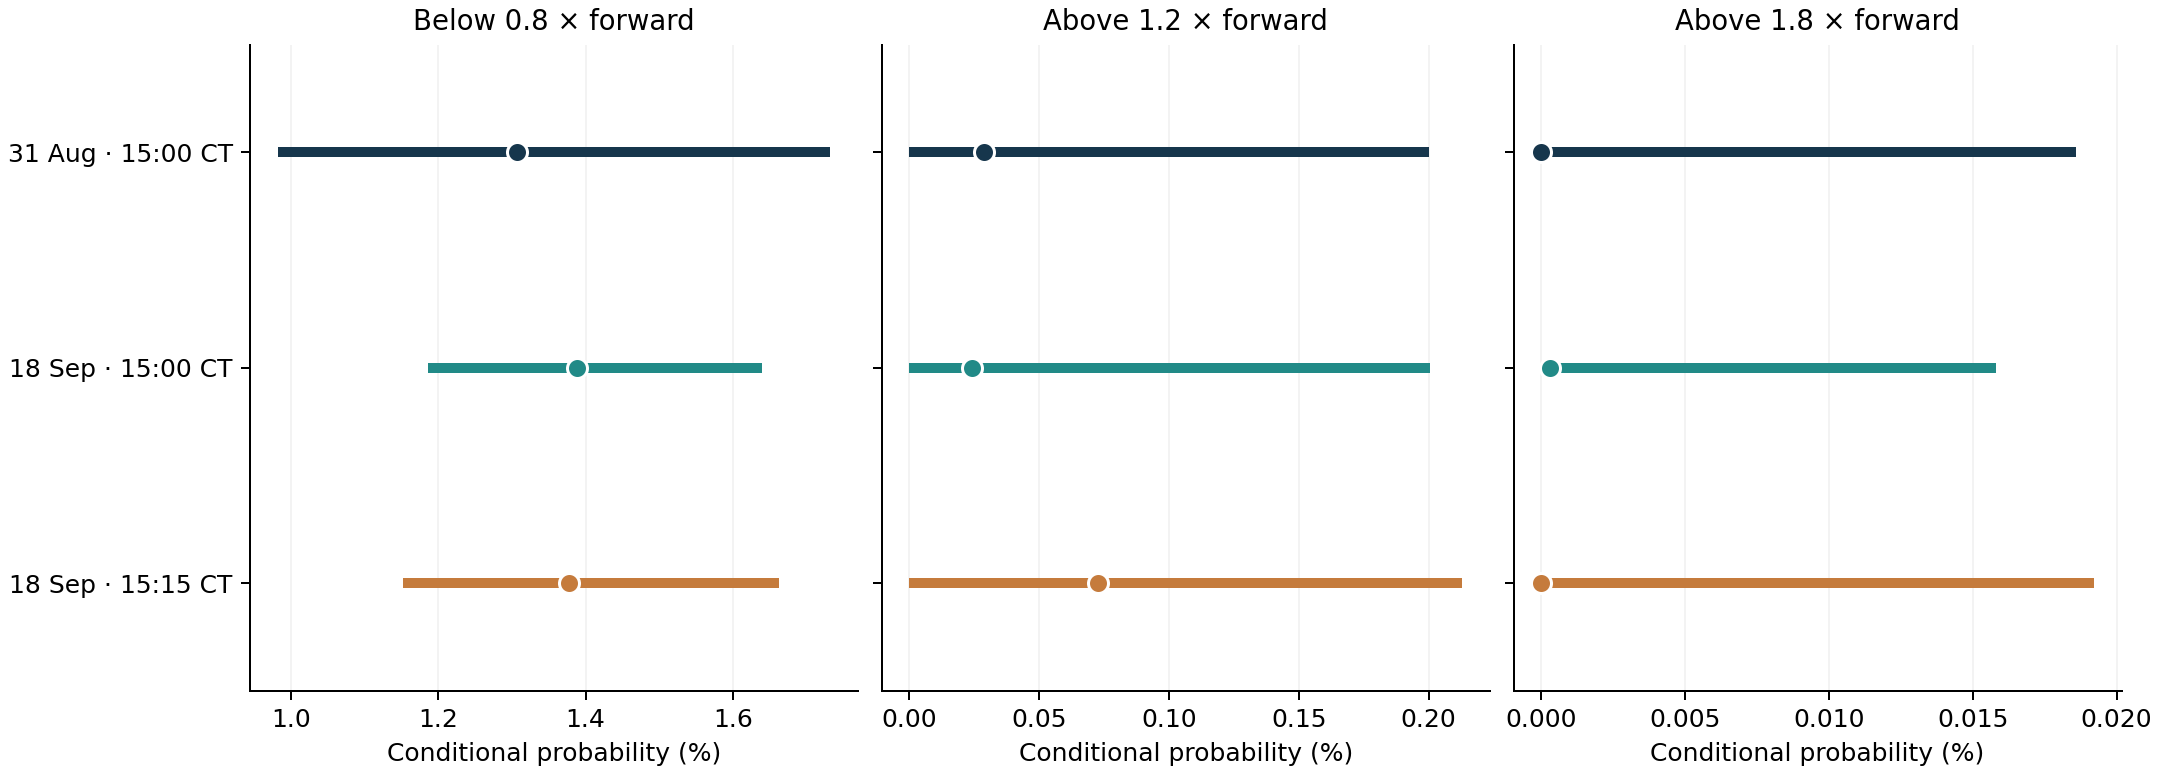




Figure 32. Dots are the minimum-curvature point estimates; horizontal bars are the conditional feasible probability ranges. Panels use different horizontal scales and percentages throughout. The bars are not statistical error bars. In particular, a nearly zero selected upper-tail probability can coexist with a materially positive feasible upper bound.

The common-60-day lower-tail ranges overlap across the dates. The upper-tail ranges are also broad relative to some selected values. These observations do not support a claim of a statistically established change or a particular market-event explanation. The dated differences remain descriptive and conditional on the declared input and modelling choices.

## 7. Date-aware 3D interaction and reproducibility



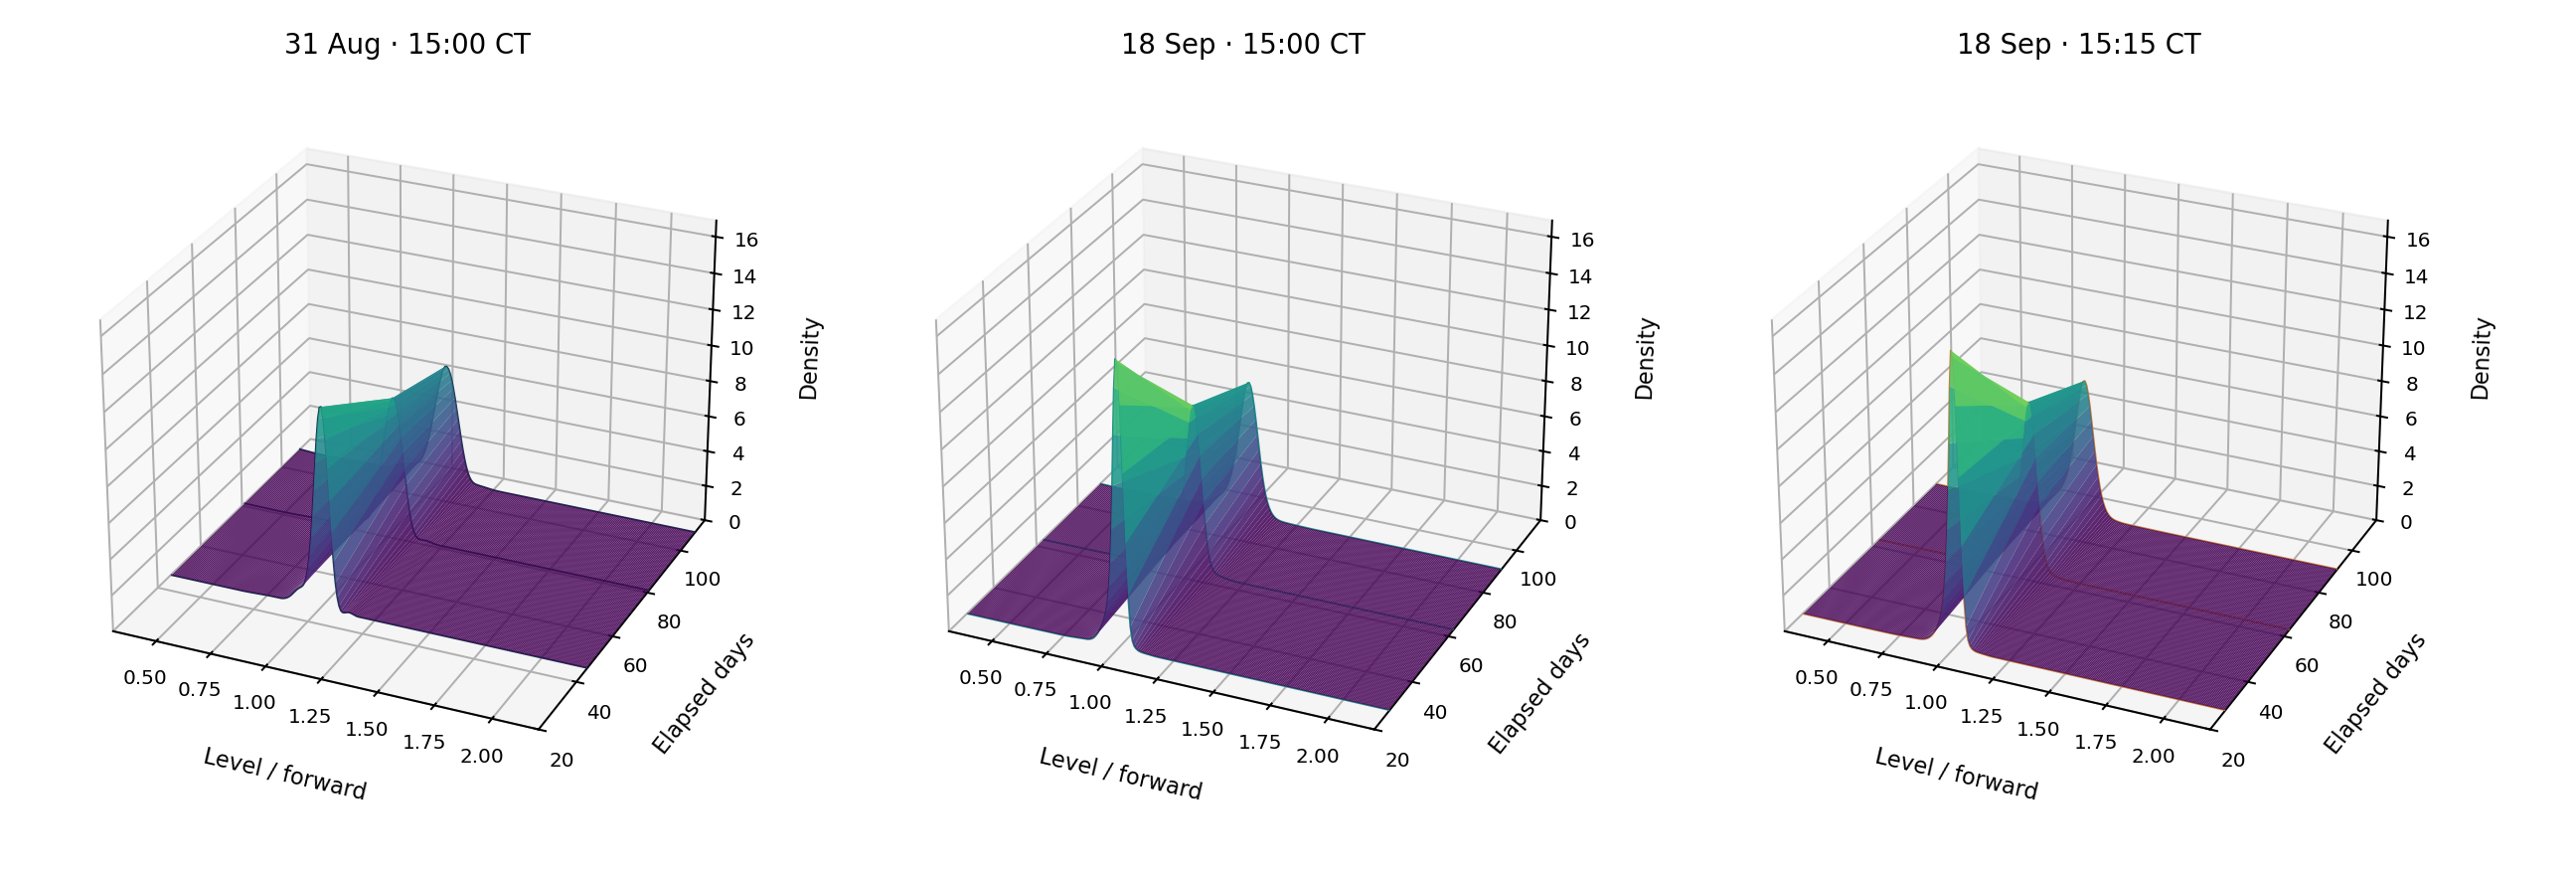




Figure 33. The three fitted surfaces on common normalised-level, elapsed-day and density scales. Only three expiry densities are fitted in each snapshot. Surface joins between bin centres and maturity rows aid viewing; they are not extra observations. The companion adds rotation, zoom, hover, observed-snapshot playback, exact histogram slices and the separately labelled 60-day mixture.

The [dated offline explorer](interactive/dated_density_surface.html) embeds its scripts and data. Playback steps through the three observations; it does not manufacture observations between the two dates. It can switch to the common-contract refits. All-pair feasible risk ranges are hidden for that control because its carry and quote family differ. Shared plot scales keep date comparisons readable. Keyboard controls and narrow-screen layouts are checked alongside the scientific values.

Run `python build_milestone10_notebook.py` from the extracted project folder to recompute the cases, figures, tables, notebook and offline explorer from archived inputs. `results/comparison_protocol.json` records post-pilot choices and numerical tolerances; `comparison_summary.json` records case accounting, environment, parent/input/code hashes and the limits of the comparison. Each case saves its feasibility solve, accepted or failed numerical attempts, masses, carry and diagnostics. The original pilots and the first aborted run's log remain available. `tests/test_comparison.py` includes an independently constructed uniform-density example, incompatible convexity example, event-bound checks and reconstruction of saved results and training-only carry.

The ten planned analytical notebooks are now complete with their limitations recorded. The next stage is assembly and editing of the final paper, including Joel Cerraga's title page, abstract, table of contents, all requested lists, the consolidated development reflection and the shared [reference register](research/references.md). Notebook completion does not remove the empirical identification, sampling and unresolved-fold limitations described here.
